<a href="https://colab.research.google.com/github/TrishaPal2003/ML_Assignment/blob/main/MidTerm_ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name : Trisha Pal
# Email : trishapal160@gmail.com

# Question 1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
age               0
workclass         0
fnlwgt            0
education         0
education-num

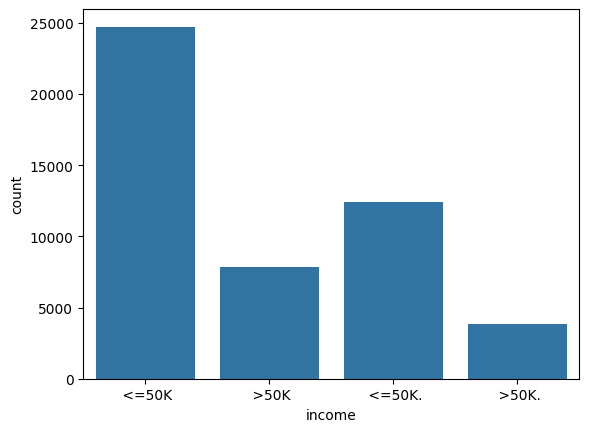

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("adult_income.csv")
df.dropna(inplace=True)
df.head(10)
df.info()
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="income", data = df)
print(df.isnull().sum())


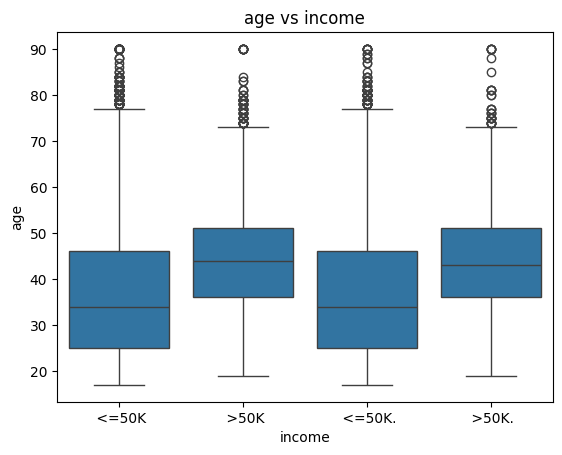

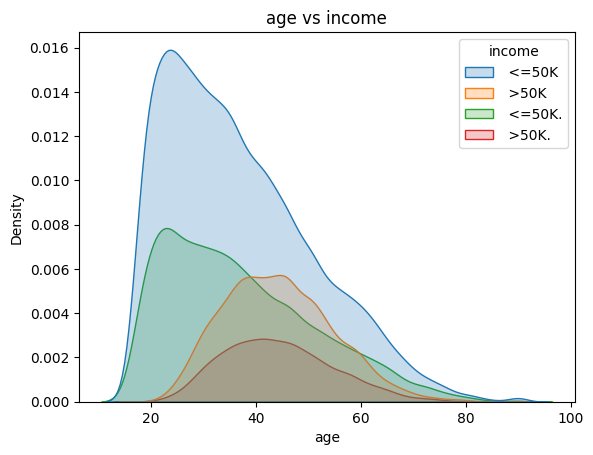

income
<=50K     36.783738
<=50K.    37.048010
>50K      44.249841
>50K.     44.326833
Name: age, dtype: float64


In [ ]:
sns.boxplot(data=df, x="income", y="age")
plt.title("age vs income")
plt.show()

sns.kdeplot(data=df, x="age", hue="income", fill=True)
plt.title("age vs income")
plt.show()

print(df.groupby("income")["age"].mean())

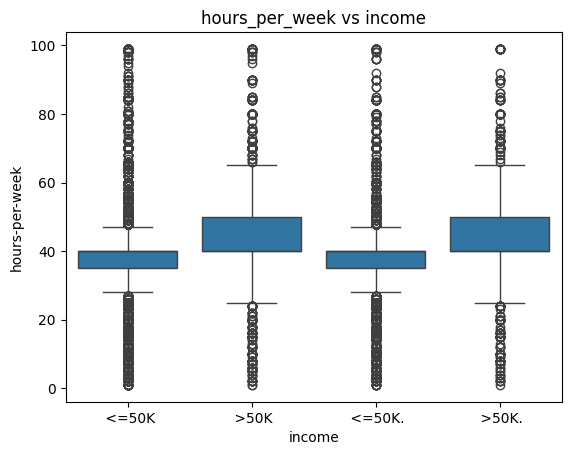

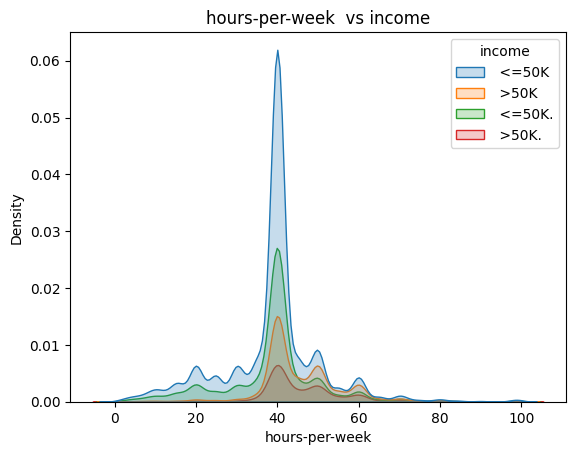

income
<=50K     38.840210
<=50K.    38.839727
>50K      45.473026
>50K.     45.411856
Name: hours-per-week, dtype: float64


In [ ]:
sns.boxplot(data=df, x="income", y="hours-per-week")
plt.title('hours_per_week vs income')
plt.show()

sns.kdeplot(data=df, x="hours-per-week", hue="income", fill=True)
plt.title('hours-per-week  vs income')
plt.show()

print(df.groupby("income")["hours-per-week"].mean())

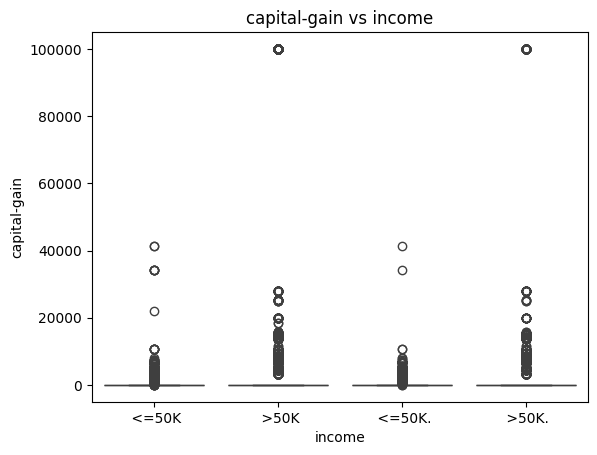

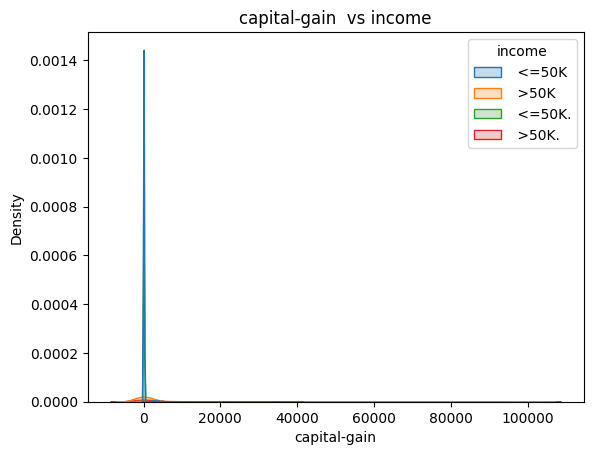

income
<=50K      148.752468
<=50K.     143.547004
>50K      4006.142456
>50K.     4115.832033
Name: capital-gain, dtype: float64


In [ ]:
sns.boxplot(data=df, x="income", y="capital-gain")
plt.title('capital-gain vs income')
plt.show()

sns.kdeplot(data=df, x="capital-gain", hue="income", fill=True)
plt.title('capital-gain  vs income')
plt.show()

print(df.groupby("income")["capital-gain"].mean())

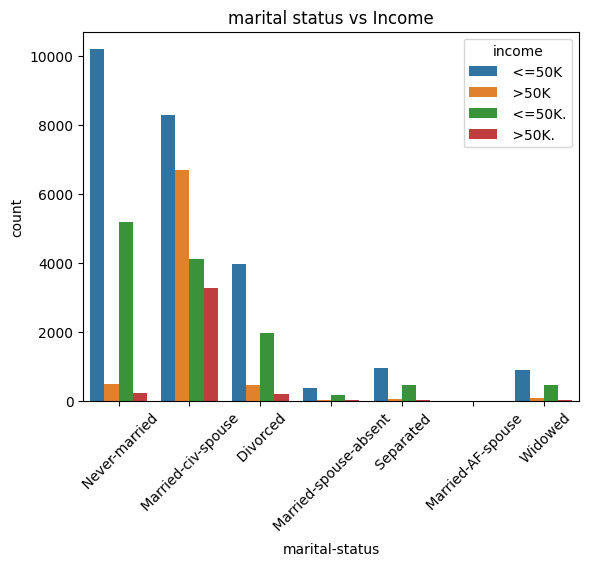

income  marital-status       
<=50K   Never-married            10192
        Married-civ-spouse        8284
        Divorced                  3980
        Separated                  959
        Widowed                    908
        Married-spouse-absent      384
        Married-AF-spouse           13
<=50K.  Never-married             5192
        Married-civ-spouse        4111
        Divorced                  1982
        Widowed                    482
        Separated                  472
        Married-spouse-absent      186
        Married-AF-spouse           10
>50K    Married-civ-spouse        6692
        Never-married              491
        Divorced                   463
        Widowed                     85
        Separated                   66
        Married-spouse-absent       34
        Married-AF-spouse           10
>50K.   Married-civ-spouse        3292
        Never-married              242
        Divorced                   208
        Widowed                   

In [ ]:
sns.countplot(data=df, x="marital-status", hue="income")
plt.xticks(rotation=45)
plt.title("marital status vs Income")
plt.show()

print(df.groupby("income")["marital-status"].value_counts())

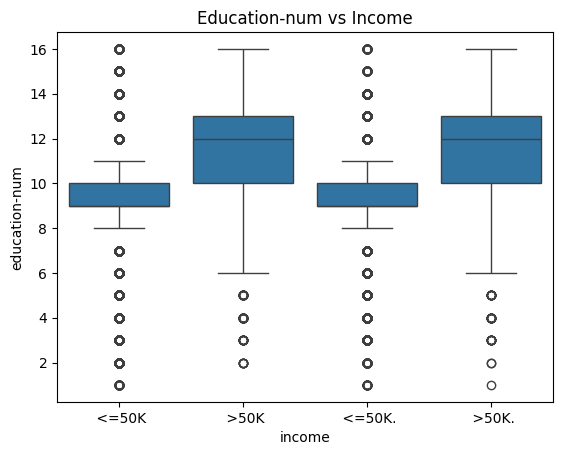

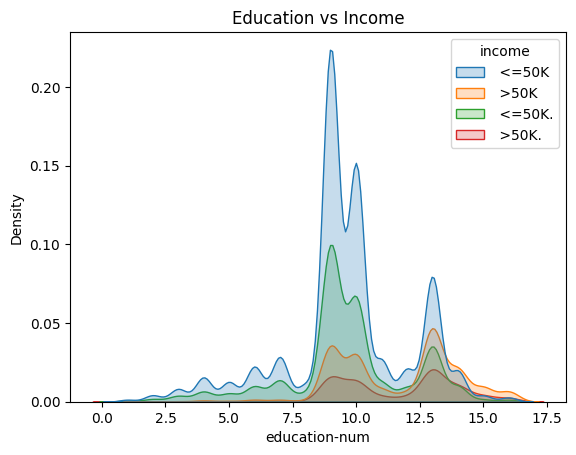

income
<=50K      9.595065
<=50K.     9.605308
>50K      11.611657
>50K.     11.584763
Name: education-num, dtype: float64


In [ ]:
sns.boxplot(data=df, x="income", y="education-num")
plt.title("Education-num vs Income")
plt.show()

sns.kdeplot(data=df, x="education-num", hue="income", fill=True)
plt.title("Education vs Income")
plt.show()

print(df.groupby("income")["education-num"].mean())

Top 3 features are Capital gain, Education num and marital status. Capital gain rank 1 cause it creates the strongest numerical separation. Education num consistently separates the two groups thats why its rank 2 and lastly marital status this is separation stronger then rest of the features.

# Question 2


In [ ]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df.drop(columns=['hours-per-week','income'])
Y = df['hours-per-week']



numerical_columns = ['age', 'capital-gain', 'capital-loss', 'education-num', 'fnlwgt']
catagorical_columns = ['workclass', 'education','occupation','relationship','race','sex','native-country']
numerical_tranformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_tranformer, numerical_columns),
        ('categorical', categorical_transformer, catagorical_columns)
    ]
)





## preprocessing documentation

here two types of data numerical and categorical .
for numerical value strategy median used cause most values are skewed as well as used standardscaler cause different features ranges.

for catagorical value strategy used most frequent cause fills missing values with most common category as well as onehotencoder used handle_inknown ignore cause converts each category into binary column. Used columntransformer cause help to merge the result


# Question 3


In [ ]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error,mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

lr_pipeline = Pipeline(
    [
        ('preprocessing', preprocessor),
        ('model', LinearRegression())
    ]
)
lr_pipeline.fit(X_train, Y_train)
y_pred = lr_pipeline.predict(X_test)

print(f"MSE: {round(mean_squared_error(Y_test, y_pred),4)}")
print(f"R2: {round(r2_score(Y_test, y_pred),4)}")
print(f"RMSE: {round(root_mean_squared_error(Y_test, y_pred),4)}")
print(f"MAE: {round(mean_absolute_error(Y_test, y_pred),4)}")




MSE: 124.6752
R2: 0.1868
RMSE: 11.1658
MAE: 7.711


In [ ]:
sgd_pipeline = Pipeline(
    [
        ('preprocessing', preprocessor),
        ('model', SGDRegressor())
    ]
)
sgd_pipeline.fit(X_train, Y_train)
y_pred_sgd = sgd_pipeline.predict(X_test)

print(f"MSE: {round(mean_squared_error(Y_test, y_pred_sgd),4)}")
print(f"R2: {round(r2_score(Y_test, y_pred_sgd),4)}")
print(f"RMSE: {round(root_mean_squared_error(Y_test, y_pred_sgd),4)}")
print(f"MAE: {round(mean_absolute_error(Y_test, y_pred_sgd),4)}")




MSE: 124.6498
R2: 0.187
RMSE: 11.1647
MAE: 7.6914


## Chose Model
Both model was perform very similar. Between two model we choose linear regresion model cause it explained more variance in the target variable and achieved lower overall prediction error.

# Question 4

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
X = df.drop(columns=['hours-per-week','income'])
Y = (df['income'] == ' >50K').astype(int)


X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42, stratify=Y)

lr_pipeline = Pipeline(
    [
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)
lr_pipeline.fit(X_train, Y_train)
y_pred = lr_pipeline.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")






Accuracy: 0.7516634251202784
Precision: 0.3753631609529343
Recall: 0.8239795918367347


# Question 5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


Knn_model = Pipeline(
    [
        ('preprocessing', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=15, metric = 'minkowski', p=2))
    ]
)


param_grid={
        'model__n_neighbors': [3, 5, 7],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1,2]
    }

grid_search = GridSearchCV(
    estimator=Knn_model,
    param_grid=param_grid,
    cv=3

)

grid_search.fit(X_train, Y_train)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)


accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")



Accuracy: 0.8355000511823114
Precision: 0.48086359175662413
Recall: 0.3125


Logistic Regression performed better overall for this classification task cause it provides a much better balance